# Previsione dei prezzi immobiliari con Ames Housing

Questo notebook costruisce una pipeline completa e riproducibile per stimare `SalePrice`: validazione del dataset, split anticipato, data wrangling senza leakage, feature engineering, preprocessing, confronto fra modelli, tuning, K-fold cross-validation, valutazione finale e deployment simulato con `predict_price(input_dict)`.

Il test set è isolato dal codice di selezione e viene aperto una sola volta per il modello già congelato. Gli output di una versione precedente avevano tuttavia già esposto questo stesso holdout: il protocollo corrente è indipendente a livello di codice, ma il benchmark non è storicamente cieco.

## 1. Contratto dei dati e ambiente

Il file `AmesHousing.csv` deve trovarsi accanto al notebook. Prima di leggere i dati verifichiamo SHA-256, schema, numero di righe, identificatori e target. Il caricamento non effettua download e conserva la distinzione tra stringa `NA` (dotazione assente) e valore realmente mancante.

La copia di riferimento proviene da [Kaggle](https://www.kaggle.com/datasets/shashanknecrothapa/ames-housing-dataset), dove il campo della licenza è indicato come `Unknown`. Il dataset non viene ridistribuito con il repository pubblico e deve essere ottenuto direttamente dalla pagina sorgente secondo le condizioni applicabili.

In [1]:
import sys
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

from ames_pipeline import (
    EXPECTED_DATASET_SHA256,
    RANDOM_STATE,
    RAW_FEATURE_COLUMNS,
    TARGET,
    AmesWrangler,
    FeatureEngineer,
    build_model_pipeline,
    evaluate_holdout,
    feature_ablation_cv,
    load_data,
    predict_price,
    run_model_selection,
    set_final_pipeline,
    shared_cv_splits,
    split_development_test,
    split_features_target,
    split_manifest_digest,
    transformed_feature_importance,
)

DATA_PATH = Path("AmesHousing.csv")
EXPECTED_TEST_MANIFEST = "1F35ED4E8036514639F34F666960E6DE3A7097F9D87480BC7FC0267AD9C4FD48"
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})
print(f"Python {sys.version.split()[0]} | seed={RANDOM_STATE}")

Python 3.12.13 | seed=42


In [2]:
df = load_data(DATA_PATH, verify_hash=True)
print(f"Dataset verificato: {df.shape[0]} righe x {df.shape[1]} colonne")
print(f"SHA-256: {EXPECTED_DATASET_SHA256}")
display(df.head())

Dataset verificato: 2930 righe x 82 colonne
SHA-256: 65A1CBB89C2B58B11674097135DD04E710DF5DB726BCFE6EC551DE38B44E4911


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,0526301100,20,RL,141.0,31770,Pave,NA,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NA,NA,NA,0,5,2010,WD,Normal,215000
1,2,0526350040,20,RH,80.0,11622,Pave,NA,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NA,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NA,MnPrv,NA,0,6,2010,WD,Normal,105000
2,3,0526351010,20,RL,81.0,14267,Pave,NA,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NA,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NA,NA,Gar2,12500,6,2010,WD,Normal,172000
3,4,0526353030,20,RL,93.0,11160,Pave,NA,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,None,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NA,NA,NA,0,4,2010,WD,Normal,244000
4,5,0527105010,60,RL,74.0,13830,Pave,NA,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NA,MnPrv,NA,0,3,2010,WD,Normal,189900


## 2. Split anticipato e holdout congelato

Lo split avviene immediatamente dopo la validazione, prima di EDA, imputazioni o scelte modellistiche. Manteniamo `test_size=0.2` e `random_state=42` per evitare di scegliere un nuovo split dopo aver visto i risultati precedenti. Un digest degli identificatori rende osservabile qualunque cambiamento futuro.

In [3]:
development_raw, test_raw = split_development_test(df)
X_development, y_development = split_features_target(development_raw)

test_manifest = split_manifest_digest(test_raw)
assert test_manifest == EXPECTED_TEST_MANIFEST, (
    f"Split test inatteso: {test_manifest}; atteso {EXPECTED_TEST_MANIFEST}."
)
development_ids = set(zip(development_raw["Order"], development_raw["PID"], strict=True))
test_ids = set(zip(test_raw["Order"], test_raw["PID"], strict=True))
assert development_ids.isdisjoint(test_ids)

print(f"Sviluppo: {development_raw.shape} | test congelato: {test_raw.shape}")
print(f"Feature grezze del modello: {len(RAW_FEATURE_COLUMNS)}")
print(f"Digest test: {test_manifest}")

Sviluppo: (2344, 82) | test congelato: (586, 82)
Feature grezze del modello: 79
Digest test: 1F35ED4E8036514639F34F666960E6DE3A7097F9D87480BC7FC0267AD9C4FD48


## 3. Comprensione ed EDA sul solo insieme di sviluppo

Da questo punto e fino alla sezione di valutazione finale lavoriamo esclusivamente su `development_raw`, `X_development` e `y_development`. Il test non contribuisce a statistiche descrittive, imputazioni, scelta delle feature, tuning o selezione.

In [4]:
price_development = development_raw[TARGET]
summary = pd.Series({
    "Conteggio": price_development.count(),
    "Media": price_development.mean(),
    "Mediana": price_development.median(),
    "Deviazione standard": price_development.std(),
    "Minimo": price_development.min(),
    "Massimo": price_development.max(),
    "Skew": price_development.skew(),
})
display(summary.to_frame("SalePrice - sviluppo"))

missing = development_raw.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame("Mancanti reali"))

,SalePrice - sviluppo
Conteggio,2344.000000
Media,178582.207765
Mediana,160000.000000
Deviazione standard,77125.072713
Minimo,12789.000000
Massimo,755000.000000
Skew,1.750597


,Mancanti reali
Lot Frontage,393
Garage Yr Blt,122
Mas Vnr Type,19
Mas Vnr Area,19
Bsmt Exposure,3
Garage Finish,2
BsmtFin Type 2,2
Garage Cars,1
Bsmt Qual,1
Bsmt Cond,1


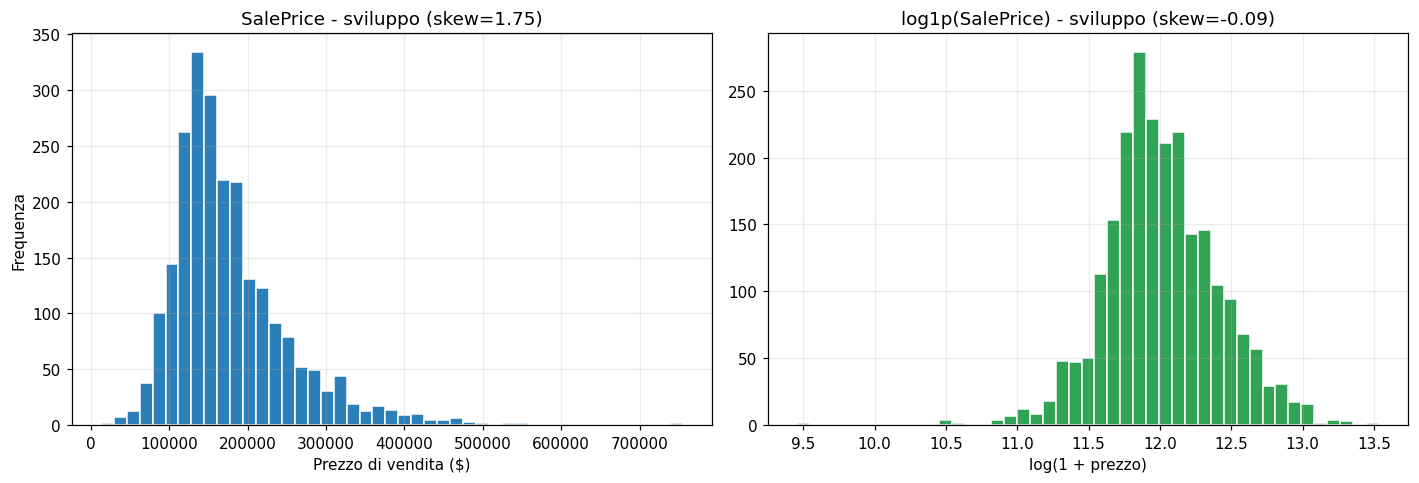

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(price_development, bins=45, color="#2c7fb8", edgecolor="white")
axes[0].set_title(f"SalePrice - sviluppo (skew={price_development.skew():.2f})")
axes[0].set_xlabel("Prezzo di vendita ($)")
axes[0].set_ylabel("Frequenza")

log_price = np.log1p(price_development)
axes[1].hist(log_price, bins=45, color="#31a354", edgecolor="white")
axes[1].set_title(f"log1p(SalePrice) - sviluppo (skew={log_price.skew():.2f})")
axes[1].set_xlabel("log(1 + prezzo)")
plt.tight_layout()
plt.show()

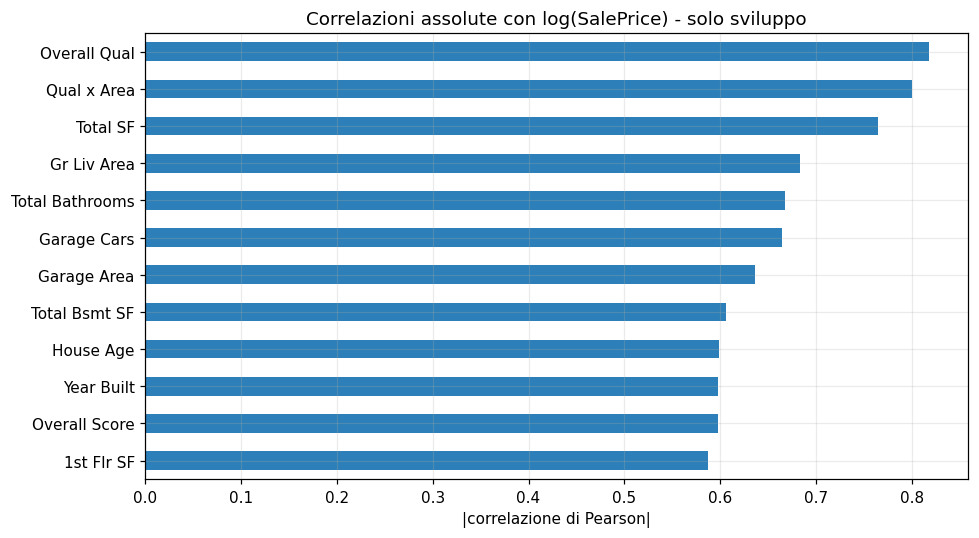

,|correlazione|
Overall Qual,0.818006
Qual x Area,0.800808
Total SF,0.764702
Gr Liv Area,0.683083
Total Bathrooms,0.668018
Garage Cars,0.664734
Garage Area,0.636837
Total Bsmt SF,0.606330
House Age,0.598793
Year Built,0.598154


In [6]:
eda_wrangler = AmesWrangler().fit(X_development)
eda_wrangled = eda_wrangler.transform(X_development)
eda_engineer = FeatureEngineer().fit(eda_wrangled)
eda_features = eda_engineer.transform(eda_wrangled)

eda_numeric = eda_features.select_dtypes(include="number").copy()
eda_numeric["log SalePrice"] = y_development.to_numpy()
correlations = (
    eda_numeric.corr(numeric_only=True)["log SalePrice"]
    .drop("log SalePrice")
    .abs()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 5))
correlations.head(12).sort_values().plot.barh(ax=ax, color="#2c7fb8")
ax.set_title("Correlazioni assolute con log(SalePrice) - solo sviluppo")
ax.set_xlabel("|correlazione di Pearson|")
plt.tight_layout()
plt.show()
display(correlations.head(12).to_frame("|correlazione|"))

In [7]:
extreme_mask = (development_raw["Gr Liv Area"] > 4000) & (development_raw[TARGET] < 300000)
extreme_cases = development_raw.loc[
    extreme_mask,
    ["Order", "PID", "Gr Liv Area", TARGET, "Sale Condition", "Overall Qual"],
]
print(f"Casi estremi osservati nello sviluppo: {len(extreme_cases)}")
display(extreme_cases)
print(
    "I casi restano nel campione: una regola che usa SalePrice non è applicabile "
    "al momento della predizione e non deve definire popolazioni diverse fra training e inference."
)

Casi estremi osservati nello sviluppo: 2


,Order,PID,Gr Liv Area,SalePrice,Sale Condition,Overall Qual
391,1499,0908154235,5642,160000,Partial,10
1634,2181,0908154195,5095,183850,Partial,10


I casi restano nel campione: una regola che usa SalePrice non è applicabile al momento della predizione e non deve definire popolazioni diverse fra training e inference.


## 4. Pipeline di wrangling, feature engineering e preprocessing

`AmesWrangler` è il primo step della pipeline sklearn. Le mediane di `Lot Frontage` e la moda di `Electrical` vengono quindi apprese separatamente dentro ogni fold. Seguono feature derivate, encoding ordinale/one-hot, trasformazione logaritmica condizionale e scaling. La stessa pipeline verrà usata senza riscritture da `predict_price()`.

In [8]:
pipeline_preview = build_model_pipeline(LinearRegression())
display(pipeline_preview)
print("Ordine degli step:", " -> ".join(pipeline_preview.named_steps))

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('wrangle', ...), ('feature_engineering', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,enabled,True
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ordinal', ...), ('nominal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If th

Ordine degli step: wrangle -> feature_engineering -> preprocess -> model


## 5. Selezione tramite K-fold cross-validation

Confrontiamo `LinearRegression`, Ridge, `RandomForestRegressor` e `XGBRegressor` sugli stessi cinque fold. Ridge, Random Forest e XGBoost usano `RandomizedSearchCV` con un inventario finito e riproducibile di configurazioni. Per applicare la regola di un errore standard, il progetto adotta l'ordine operativo di parsimonia `LinearRegression`, Ridge, Random Forest, XGBoost; non è una misura matematica universale della complessità.

La metrica di selezione è RMSE sulla scala logaritmica. MAE e R² sono descrittive. La regola di un errore standard preferisce il candidato meno complesso quando le differenze sono inferiori alla variabilità osservata. Nessuna variabile del test viene passata a questa fase.

In [9]:
cv_splits = shared_cv_splits(X_development, y_development, n_splits=5)
selection = run_model_selection(
    X_development,
    y_development,
    cv_splits=cv_splits,
)

print("METRICHE DI SELEZIONE CV - non sono metriche del test finale")
display(selection.table.round({
    "RMSE": 4,
    "RMSE_std": 4,
    "MAE": 4,
    "R2": 4,
}))
print(f"Soglia di un errore standard: {selection.one_standard_error_threshold:.4f}")
print(f"Modello congelato prima del test: {selection.selected_name}")

METRICHE DI SELEZIONE CV - non sono metriche del test finale


,RMSE,RMSE_std,MAE,R2
Modello,,,,
XGBoost,0.1236,0.0242,0.0794,0.9029
Ridge,0.1284,0.0306,0.0828,0.8943
RandomForest,0.1323,0.0249,0.0857,0.8891
LinearRegression,0.1323,0.0277,0.0841,0.8884


Soglia di un errore standard: 0.1345
Modello congelato prima del test: LinearRegression


## 6. Ablazione delle feature derivate

L'importanza per gain descrive come un modello ad albero usa le feature, ma non dimostra che le feature derivate migliorino la previsione. Eseguiamo quindi un confronto appaiato con e senza `FeatureEngineer`, usando il modello congelato e gli stessi fold di sviluppo. Un delta negativo indica RMSE inferiore con le feature derivate.

,Con feature derivate,Senza feature derivate,Delta (con - senza)
Fold 1,0.1060,0.1082,-0.0022
Fold 2,0.1328,0.1309,0.0019
Fold 3,0.1197,0.1227,-0.0030
Fold 4,0.1180,0.1201,-0.0021
Fold 5,0.1852,0.1872,-0.0021


Delta medio RMSE (con - senza): -0.0015


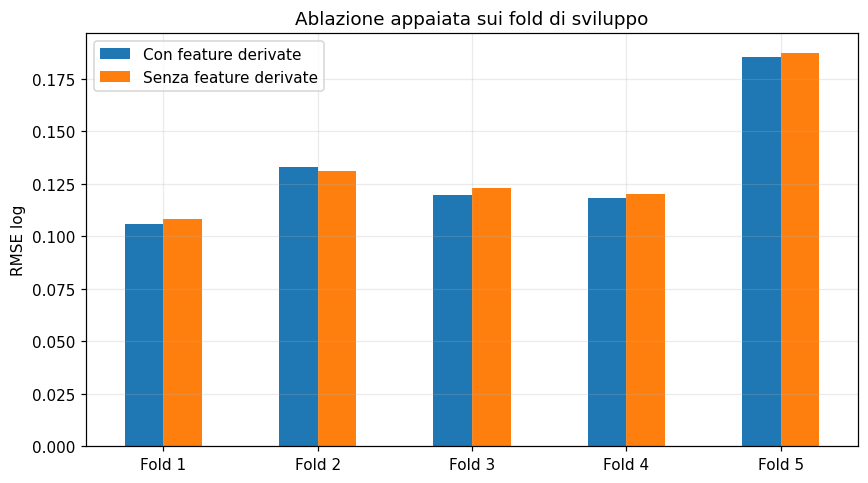

In [10]:
ablation = feature_ablation_cv(
    selection.selected_estimator,
    X_development,
    y_development,
    cv_splits,
)
display(ablation.round(4))
print(f"Delta medio RMSE (con - senza): {ablation['Delta (con - senza)'].mean():+.4f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ablation[["Con feature derivate", "Senza feature derivate"]].plot.bar(ax=ax)
ax.set_ylabel("RMSE log")
ax.set_title("Ablazione appaiata sui fold di sviluppo")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 7. Valutazione finale del solo modello congelato

Il test viene aperto qui per la prima e unica valutazione del protocollo corrente. Non confrontiamo candidati sul test e nessuna metrica successiva può cambiare famiglia, feature o iperparametri. `selection.selected_estimator` è già stato rifittato su tutto l'insieme di sviluppo dalla procedura di selezione.

In [11]:
final_pipeline = selection.selected_estimator
X_test, y_test = split_features_target(test_raw)
holdout_metrics, test_prediction_log, residuals = evaluate_holdout(
    final_pipeline,
    X_test,
    y_test,
)
holdout_metrics.index = [selection.selected_name]
print("VALUTAZIONE FINALE - una sola riga, un solo modello")
display(holdout_metrics.round({
    "RMSE log": 4,
    "MAE log": 4,
    "R2 log": 4,
    "RMSE $": 0,
    "MAE $": 0,
    "MAPE %": 2,
}))

VALUTAZIONE FINALE - una sola riga, un solo modello


,RMSE log,MAE log,R2 log,RMSE $,MAE $,MAPE %
LinearRegression,0.1109,0.076,0.9335,27270.0,14721.0,7.71


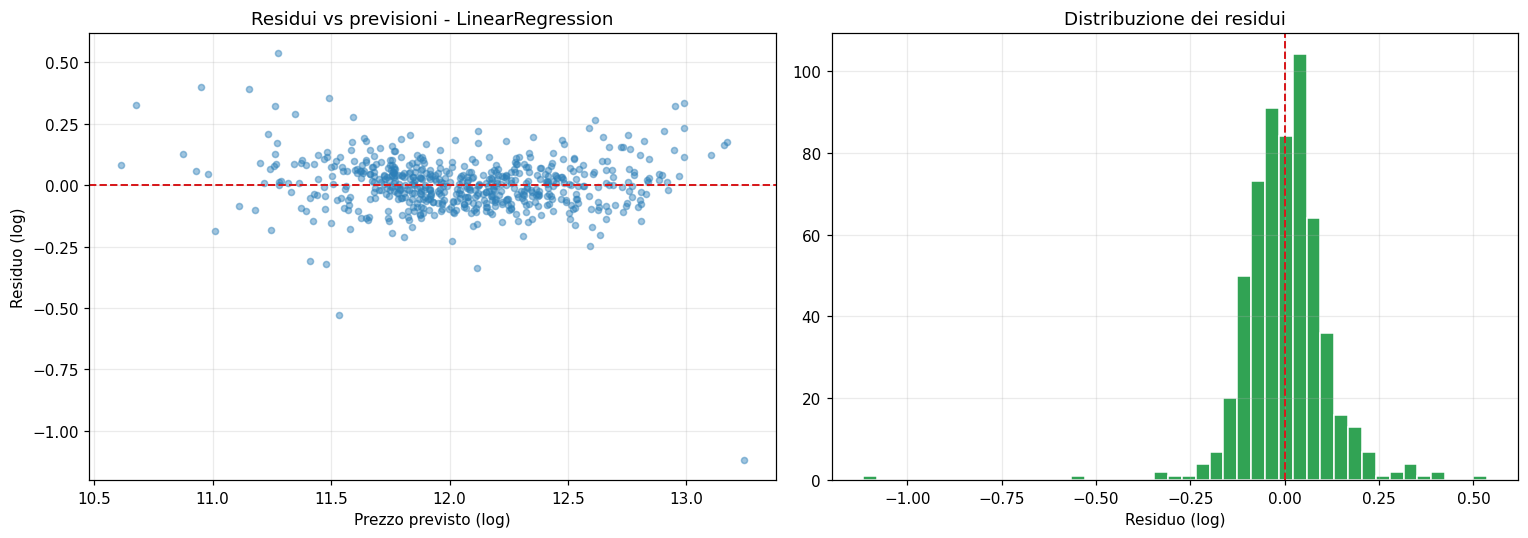

Residui - media=+0.0038, dev.std=0.1109, skew=-1.445
La distribuzione non è simmetrica: analizziamo esplicitamente la coda degli errori.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(test_prediction_log, residuals, s=16, alpha=0.45, color="#2c7fb8")
axes[0].axhline(0, color="#d7191c", linestyle="--", linewidth=1.3)
axes[0].set_xlabel("Prezzo previsto (log)")
axes[0].set_ylabel("Residuo (log)")
axes[0].set_title(f"Residui vs previsioni - {selection.selected_name}")

axes[1].hist(residuals, bins=45, color="#31a354", edgecolor="white")
axes[1].axvline(0, color="#d7191c", linestyle="--", linewidth=1.3)
axes[1].set_xlabel("Residuo (log)")
axes[1].set_title("Distribuzione dei residui")
plt.tight_layout()
plt.show()

residual_series = pd.Series(residuals)
print(
    f"Residui - media={residual_series.mean():+.4f}, "
    f"dev.std={residual_series.std():.4f}, skew={residual_series.skew():+.3f}"
)
if abs(residual_series.skew()) >= 0.5:
    print("La distribuzione non è simmetrica: analizziamo esplicitamente la coda degli errori.")

In [13]:
error_analysis = test_raw[["Order", "PID", TARGET, "Gr Liv Area", "Overall Qual"]].copy()
error_analysis["Predizione $"] = np.expm1(test_prediction_log)
error_analysis["Errore assoluto $"] = (
    error_analysis[TARGET] - error_analysis["Predizione $"]
).abs()
print("Dieci osservazioni con errore assoluto maggiore:")
display(error_analysis.nlargest(10, "Errore assoluto $"))

Dieci osservazioni con errore assoluto maggiore:


,Order,PID,SalePrice,Gr Liv Area,Overall Qual,Predizione $,Errore assoluto $
89,2182,0908154205,184750,4676,10,565091.709904,380341.709904
173,45,0528150070,611657,2364,9,437431.661376,174225.338624
450,434,0528110090,582933,2822,9,421903.323690,161029.676310
582,457,0528176030,552000,2492,10,437551.974806,114448.025194
125,2446,0528320060,625000,3627,10,525261.263542,99738.736458
175,367,0527214050,501837,2234,9,403269.560527,98567.439473
511,433,0528110020,610000,2674,10,518345.442487,91654.557513
101,1560,0911370410,392500,1652,8,300863.179764,91636.820236
327,2098,0906340090,424870,2828,8,346125.007221,78744.992779
211,1588,0921201060,370000,1964,8,293622.016948,76377.983052


## 8. Tabella comparativa e interpretazione

La tabella comparativa resta quella della cross-validation sullo sviluppo. Il test non viene esteso ai modelli perdenti. Per XGBoost mostriamo l'importanza per gain come descrizione del modello addestrato sullo sviluppo; il risultato dell'ablazione, non il gain, è l'evidenza pertinente sul contributo delle feature derivate.

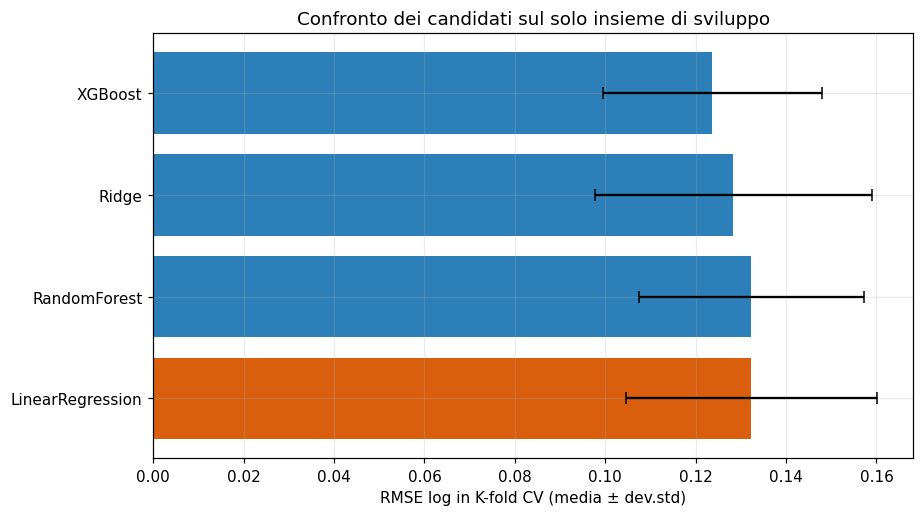

In [14]:
comparison = selection.table.copy()
fig, ax = plt.subplots(figsize=(8.5, 4.8))
plot_names = list(comparison.index[::-1])
ax.barh(
    plot_names,
    comparison["RMSE"].iloc[::-1],
    xerr=comparison["RMSE_std"].iloc[::-1],
    color=["#d95f0e" if name == selection.selected_name else "#2c7fb8" for name in plot_names],
    capsize=4,
)
ax.set_xlabel("RMSE log in K-fold CV (media ± dev.std)")
ax.set_title("Confronto dei candidati sul solo insieme di sviluppo")
plt.tight_layout()
plt.show()

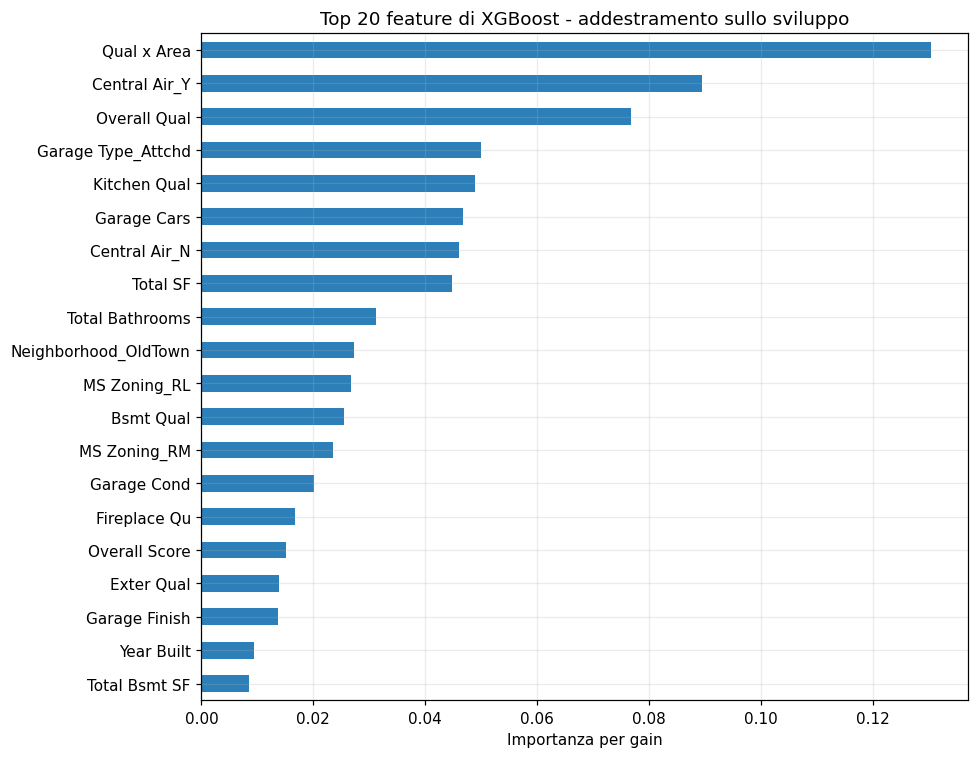

,gain
Qual x Area,0.130476
Central Air_Y,0.089383
Overall Qual,0.076808
Garage Type_Attchd,0.049930
Kitchen Qual,0.048956
Garage Cars,0.046793
Central Air_N,0.046019
Total SF,0.044801
Total Bathrooms,0.031224
Neighborhood_OldTown,0.027334


In [15]:
xgb_pipeline = selection.fitted_candidates["XGBoost"]
xgb_importance = transformed_feature_importance(xgb_pipeline)
top20 = xgb_importance.head(20).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
top20.plot.barh(ax=ax, color="#2c7fb8")
ax.set_xlabel("Importanza per gain")
ax.set_title("Top 20 feature di XGBoost - addestramento sullo sviluppo")
plt.tight_layout()
plt.show()
display(xgb_importance.head(20).to_frame("gain"))

## 9. Deployment simulato: `predict_price(input_dict)`

Il contratto richiede esattamente le 79 feature grezze, vieta `SalePrice`, `Order` e `PID`, rifiuta campi mancanti o inattesi, valida tipi/range/coerenza semantica e restituisce un `float` positivo in dollari. Le categorie ordinali sconosciute sono errori; le categorie nominali nuove sono accettate e gestite dall'encoder. La funzione usa la stessa pipeline già valutata, senza rifit e senza duplicare il preprocessing.

In [16]:
set_final_pipeline(final_pipeline)
example_input = X_development.iloc[300].to_dict()
example_price = predict_price(example_input)
print(f"Campi ricevuti: {len(example_input)}")
print(f"Prezzo previsto: ${example_price:,.2f}")

Campi ricevuti: 79
Prezzo previsto: $282,859.52


## 10. Riproducibilità

Dati, split, seed, inventario degli iperparametri e dipendenze sono fissati. Una riproduzione completa richiede l'ambiente CPU specificato in `requirements.txt`, l'esecuzione dall'inizio alla fine senza stato preesistente e la verifica che hash, digest dello split e metriche rientrino nelle tolleranze approvate. Nessuna cella scarica dati o installa pacchetti.

In [17]:
packages = [
    "numpy",
    "pandas",
    "matplotlib",
    "scipy",
    "scikit-learn",
    "xgboost",
    "nbformat",
    "nbclient",
]
print(f"Python=={sys.version.split()[0]}")
for package in packages:
    try:
        print(f"{package}=={version(package)}")
    except PackageNotFoundError:
        print(f"{package}==MISSING")

Python==3.12.13
numpy==1.26.4
pandas==2.2.3
matplotlib==3.10.9
scipy==1.15.3
scikit-learn==1.8.0
xgboost==3.0.2
nbformat==5.10.4
nbclient==0.10.2


In [18]:
metric_row = holdout_metrics.iloc[0]
print("RIEPILOGO FINALE")
print(f"Modello selezionato senza test: {selection.selected_name}")
print(f"RMSE log test: {metric_row['RMSE log']:.4f}")
print(f"MAE log test:  {metric_row['MAE log']:.4f}")
print(f"R² log test:   {metric_row['R2 log']:.4f}")
print(f"MAE test:      ${metric_row['MAE $']:,.0f}")
print(f"Skew residui:  {pd.Series(residuals).skew():+.3f}")
print(f"Delta medio ablation (con - senza): {ablation['Delta (con - senza)'].mean():+.4f}")

RIEPILOGO FINALE
Modello selezionato senza test: LinearRegression
RMSE log test: 0.1109
MAE log test:  0.0760
R² log test:   0.9335
MAE test:      $14,721
Skew residui:  -1.445
Delta medio ablation (con - senza): -0.0015


## Conclusioni

La pipeline separa selezione e valutazione finale, apprende tutte le statistiche di preprocessing all'interno dei fold e usa lo stesso oggetto per training e inference. LinearRegression, Ridge, Random Forest e XGBoost sono confrontati sul solo sviluppo; il test produce una sola riga di metriche per il modello già congelato.

Il limite principale resta storico: lo stesso holdout era stato osservato in una precedente esecuzione. Le metriche correnti documentano quindi un protocollo corretto e riproducibile, ma non sostituiscono una futura verifica su dati etichettati realmente nuovi.